## **FOLPS Run Demo (JAX)**
This notebook demonstrates how to use FOLPS to compute the **power spectrum** and **bispectrum**.  

### Set the backend
Select the backend (`numpy` or `jax`). In this notebook, we use `jax`.  
For an example with `numpy`, see [link]. 

In [1]:
import os

# Select the backend before importing folps.py
os.environ["FOLPS_BACKEND"] = "jax"  #'numpy' or 'jax'

from folps import *
from cosmo_class import *

⚠️ No GPU found. Using JAX with CPU.


### Linear power spectrum  
The linear power spectrum can be computed using CLASS. If CLASS is not available, it will be loaded automatically instead.  
Additionally, some cosmological parameters must be provided as input (see `kwargs`).  

In [2]:
use_class = False
try:
    # try to import the CLASS-based runner; if Class isn't installed it will load a precomputed file
    from cosmo_class import run_class
    from classy import Class as _Class  # noqa: F401
except Exception:
    use_class = False

if use_class:
    classy  = run_class(h = 0.6711, ombh2 = 0.022, omch2 = 0.122, omnuh2 = 0.0006442, 
                        As = 2e-9, ns = 0.965, z = 0.3, z_scale=[0.97],
                        N_ur = 2.0328,
                        khmin = 0.0001, khmax = 2.0, nbk = 1000, spectra = 'cb')
else:
    # Fallback: read precomputed k, pk from the repository file (do not create a cosmo object)
    data_path = 'inputpkT.txt'
    k_arr, pk_arr = np.loadtxt(data_path, unpack=True)

    # Provide k and pk only
    classy = {'k': k_arr, 'pk': pk_arr}

# kwargs used by other parts of the notebook
kwargs = {'z': 0.3,
          'h': 0.6711,
          'Omega_m': 0.3211636237981114,
          'f0': np.float64(0.6880638641959066),
          'fnu': 0.004453689063655854}

### Matrices  
Compute the matrices required for the non-linear power spectrum.  
**They do not depend on cosmology**, so they are **calculated only once.**  

In [3]:
matrix = MatrixCalculator(A_full=True)
mmatrices = matrix.get_mmatrices()

Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy


### Non-linear Power Spectrum
Computation of the non-linear power spectrum.  
In the `NonLinearPowerSpectrumCalculator` class, you can choose between the `fk` or `EdS` kernel.

In [4]:
%%time
nonlinear = NonLinearPowerSpectrumCalculator(mmatrices=mmatrices,
                                             kernels='fk',
                                             **kwargs)

CPU times: user 2.22 ms, sys: 1.81 ms, total: 4.03 ms
Wall time: 3.39 ms


In [12]:
%%time
k_, pk_ = extrapolate_pklin(k=classy['k'], pk=classy['pk'])
pknow = get_pknow_jax(k=k_, pk=pk_, h=kwargs['h'])

CPU times: user 2.46 ms, sys: 1.01 ms, total: 3.48 ms
Wall time: 2.79 ms


In [14]:
%%time
table, table_now = nonlinear.calculate_loop_table(k=classy['k'], pklin=classy['pk'],pknow=pknow, cosmo=None, **kwargs)

CPU times: user 105 ms, sys: 15.7 ms, total: 120 ms
Wall time: 63.7 ms


### Nuisance parameters  
Set the nuisance parameters (bias, EFT, stochastic terms).  
Also specify the Alcock–Paczynski parameters `qpar` and `qper`.  

In [15]:
# Bias parameters
b1 = 1.645
b2 = -0.46
bs2 = -4./7*(b1 - 1)
b3nl = 32./315*(b1 - 1)
# EFT parameters
alpha0 = 3                 #units: [Mpc/h]^2
alpha2 = -28.9             #units: [Mpc/h]^2
alpha4 = 0.0               #units: [Mpc/h]^2
ctilde = 0.0               #units: [Mpc/h]^4
# Stochatic parameters
PshotP = 1. / 0.0002118763
alphashot0 = 0.08
alphashot2 = -8.1          #units: [Mpc/h]^2
X_Fog_pk = 1
pars = [b1, b2, bs2, b3nl, alpha0, alpha2, alpha4, ctilde, alphashot0, alphashot2, PshotP, X_Fog_pk]

qpar, qper = qpar_qperp(Omega_fid=0.31, Omega_m=kwargs['Omega_m'], z_pk=kwargs['z'])


k = np.logspace(np.log10(0.01), np.log10(0.3), num=100) # array of  output k in [h/Mpc]

### Compute the power spectrum multipoles
You can select your preferred model: `'EFT'`, `'FOLPSD'`, or `'TNS'`.    

In [17]:
%%time
multipoles = RSDMultipolesPowerSpectrumCalculator(model='FOLPSD') 
P0, P2, P4  = multipoles.get_rsd_pkell(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor'
                                       )

[FOLPS] Model Pk: FOLPSD, Damping: lor
CPU times: user 25.5 ms, sys: 4.13 ms, total: 29.6 ms
Wall time: 22.5 ms


In [18]:
#For marginalization:
P0_c, P2_c, P4_c  = get_rsd_pkell_marg_const(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', model = 'FOLPSD'
                                       )

P0_i, P2_i, P4_i  = get_rsd_pkell_marg_derivatives(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', model = 'FOLPSD'
                                       )

P0_marg = P0_c + (alpha0 * P0_i[0] + alpha2 * P0_i[1] + alpha4 * P0_i[2] + alphashot0 * P0_i[3]+ alphashot2 * P0_i[4])
P2_marg = P2_c + (alpha0 * P2_i[0] + alpha2 * P2_i[1] + alpha4 * P2_i[2] + alphashot0 * P2_i[3]+ alphashot2 * P2_i[4])
P4_marg = P4_c + (alpha0 * P4_i[0] + alpha2 * P4_i[1] + alpha4 * P4_i[2] + alphashot0 * P4_i[3]+ alphashot2 * P4_i[4])

[FOLPS] Model Pk: FOLPSD, Damping: lor


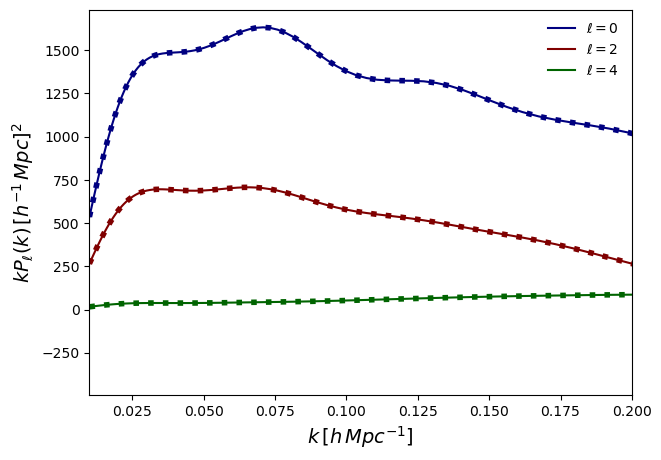

In [19]:
import matplotlib
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(7,5))
axs.set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize =  14)
axs.set_ylabel(r'$k P_{\ell}(k) \, [h^{-1} \,  Mpc]^2$', fontsize =  14)

axs.plot(k, k * P0, color = 'navy', ls='-', label=r'$\ell = 0$')
axs.plot(k, k * P2, color = 'maroon', ls='-', label=r'$\ell = 2$')
axs.plot(k, k * P4, color = 'darkgreen', ls='-', label=r'$\ell = 4$')


axs.plot(k, k * P0_marg, color = 'navy', ls=':', lw=4)
axs.plot(k, k * P2_marg, color = 'maroon', ls=':', lw=4)
axs.plot(k, k * P4_marg, color = 'darkgreen', ls=':', lw=4)

axs.set_xlim([k[0], 0.2])
#axs.set_ylim([-200.0, 1800])

leg1 = axs.legend(loc = 'best');
leg1.get_frame().set_linewidth(0.0);

plt.show()

### JAX JIT 😉

In [20]:
#jit
import jax
import jax.numpy as jnp

@jax.jit
def compute_pkells(k, pklin, qpar, qper, pars, kwargs):
    nonlinear = NonLinearPowerSpectrumCalculator(
        mmatrices=mmatrices,
        kernels='fk',
        **kwargs
    )
    
    table, table_now = nonlinear.calculate_loop_table(
        k=jnp.asarray(classy['k']),
        pklin=jnp.asarray(classy['pk']),
        #pknow=jnp.asarray(pknow_jax),
        #cosmo=classy['cosmo'],
        **kwargs
    )

    multipoles = RSDMultipolesPowerSpectrumCalculator(model='FOLPSD') 
    
    P0, P2, P4  = multipoles.get_rsd_pkell(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor'
                                       )
    return P0, P2, P4

In [22]:
%%time
# Pass the precomputed pknow into the jitted function
P0_j, P2_j, P4_j = compute_pkells(k=k,  pklin=classy['pk'], qpar=qpar, qper=qper, pars=pars, kwargs=kwargs)

CPU times: user 1.72 ms, sys: 613 μs, total: 2.33 ms
Wall time: 827 μs


## Bispectrum
Set the nuisance parameters for the bispectrum computation.  

In [23]:
#pars for Bispectrum
Pshot = 0; # This would be the same as PshopP*alphashot0 if the bispectrum were computed up to 1loop (I think!)
Bshot = 0;
c1=0
c2=0
X_FoG_bk=1

f0 = nonlinear.f0

bpars = [b1, b2, bs2, c1, c2, Bshot, Pshot, X_FoG_bk]

In [24]:
ks = np.logspace(np.log10(0.0001), np.log10(0.4), 30)
k1k2T = np.vstack([ks,ks]).T

Here you can select your preferred bispectrum basis: `sugiyama` or `scoccimarro` (the latter is not yet implemented).  
You can also choose your preferred model: `'EFT'`, `'FOLPSD'`, or `'TNS'`.  

In [25]:
bispectrum = BispectrumCalculator(basis='sugiyama', model = 'FOLPSD')

In [26]:
k_pkl_pklnw = np.array([table[0], table[1], table_now[1]])

In [27]:
%%time
B000, B202 = bispectrum.Bisp_Sugiyama(f=f0,  bpars=bpars,
                                      k_pkl_pklnw=k_pkl_pklnw, z_pk=kwargs['z'],
                                      k1k2pairs=k1k2T, qpar=1, qper=1, precision=[10,8,8], damping='lor')

[FOLPS] Model Bk: FOLPSD, Damping: lor
CPU times: user 2.1 s, sys: 36.4 ms, total: 2.13 s
Wall time: 2.09 s


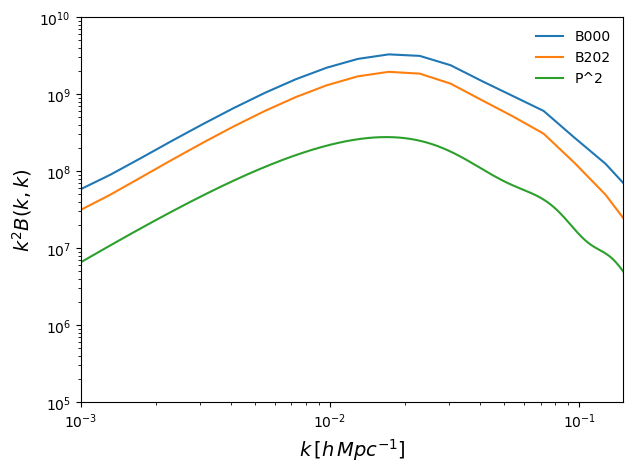

In [28]:
fig, axs = plt.subplots(figsize=(7,5))
axs.set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize =  14)
axs.set_ylabel(r'$k^2 B(k,k) $', fontsize =  14)



axs.loglog(k1k2T.T[0],B000, ls='-', label='B000')
axs.loglog(k1k2T.T[0],B202, ls='-', label='B202')
axs.loglog(nonlinear.inputpkT[0],nonlinear.inputpkT[1]*nonlinear.inputpkT[1], ls='-', label='P^2')



axs.set_xlim([0.001,0.15])
axs.set_ylim([1e5, 1e10])

leg1 = axs.legend(loc = 'best');
leg1.get_frame().set_linewidth(0.0);

plt.show()

### JAX JIT 😉

In [29]:
import jax


@jax.jit
def compute_bispectrum(bpars, f, qpar, qper):
    """
    Función compilada con JAX para calcular los monopolos del bispectrum.
    """
    bispectrum = BispectrumCalculator(basis='sugiyama', model='FOLPSD')

    B000, B202 = bispectrum.Bisp_Sugiyama(f=f, bpars=bpars,
                                          k_pkl_pklnw=k_pkl_pklnw, 
                                          z_pk=kwargs['z'],
                                          k1k2pairs=k1k2T, 
                                          qpar=qpar, 
                                          qper=qper, 
                                          precision=[10, 8, 8], 
                                          damping='lor')
    
    return B000, B202


In [31]:
%%time
B000_result, B202_result = compute_bispectrum(bpars, f0, qpar=qpar, qper=qper)

CPU times: user 951 μs, sys: 633 μs, total: 1.58 ms
Wall time: 874 μs
